# 📊 Avance 2: Gradient Boosting y Stacking

## 🎯 Objetivo

Implementar y comparar algoritmos avanzados de Gradient Boosting y técnicas de ensemble para predecir el churn de clientes bancarios.

## 📋 Contenido

1. **Random Forest**: Modelo baseline de ensemble
2. **XGBoost con GridSearch**: Optimización exhaustiva de hiperparámetros
3. **LightGBM**: Gradient Boosting optimizado para velocidad
4. **CatBoost**: Manejo automático de variables categóricas
5. **Stacking Ensemble**: Combinación de modelos con meta-learner
6. **Optuna (Opcional)**: Optimización bayesiana con 50 trials

## 🔑 Requisitos Técnicos

- **Validación Cruzada**: StratifiedKFold para datos desbalanceados
- **Métricas**: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **Optimización**: GridSearch obligatorio para XGBoost, Optuna opcional
- **Feature Importance**: Análisis de importancia de variables

---

## 1️⃣ Importación de Librerías

In [5]:
# Manipulación de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Machine Learning - Preprocesamiento
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_val_score, 
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    classification_report, confusion_matrix
)

# Algoritmos de Gradient Boosting
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Ensemble Methods
from sklearn.ensemble import StackingClassifier

# Optimización
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

print("✅ Librerías importadas correctamente")
print(f"XGBoost versión: {xgb.__version__}")
print(f"LightGBM versión: {lgb.__version__}")
print(f"CatBoost versión: {cb.__version__}")
print(f"Optuna versión: {optuna.__version__}")

✅ Librerías importadas correctamente
XGBoost versión: 3.0.1
LightGBM versión: 4.6.0
CatBoost versión: 1.2.8
Optuna versión: 4.5.0


## 2️⃣ Carga y Preparación de Datos

Cargamos el dataset y preparamos los datos siguiendo el mismo proceso del Avance 1.

In [6]:
# Cargar datos
df = pd.read_csv('Churn_Modelling.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nValores nulos: {df.isnull().sum().sum()}")

# Eliminar columnas irrelevantes
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Codificar variables categóricas
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-hot encoding para Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Separar features y target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Escalar features numéricas
scaler = StandardScaler()
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Train-test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nDistribución de clases en train: {y_train.value_counts(normalize=True)}")
print(f"Distribución de clases en test: {y_test.value_counts(normalize=True)}")

Dataset shape: (10000, 14)

Columnas: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Valores nulos: 0

Train shape: (8000, 11)
Test shape: (2000, 11)

Distribución de clases en train: Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64
Distribución de clases en test: Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


## 3️⃣ Función de Evaluación

Creamos una función para evaluar todos los modelos de manera consistente.

In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evalúa un modelo y retorna métricas detalladas"""
    
    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Probabilidades para AUC
    if hasattr(model, 'predict_proba'):
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]
        auc_train = roc_auc_score(y_train, y_proba_train)
        auc_test = roc_auc_score(y_test, y_proba_test)
    else:
        auc_train = auc_test = None
    
    # Métricas de clasificación
    metrics = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_pred_train),
        'Test_Accuracy': accuracy_score(y_test, y_pred_test),
        'Train_Precision': precision_score(y_train, y_pred_train),
        'Test_Precision': precision_score(y_test, y_pred_test),
        'Train_Recall': recall_score(y_train, y_pred_train),
        'Test_Recall': recall_score(y_test, y_pred_test),
        'Train_F1': f1_score(y_train, y_pred_train),
        'Test_F1': f1_score(y_test, y_pred_test),
        'Train_AUC': auc_train,
        'Test_AUC': auc_test
    }
    
    return metrics

def plot_confusion_matrix_and_roc(model, X_test, y_test, model_name):
    """Grafica matriz de confusión y curva ROC"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Matriz de confusión
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title(f'Matriz de Confusión - {model_name}')
    ax1.set_xlabel('Predicho')
    ax1.set_ylabel('Real')
    
    # Curva ROC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title(f'Curva ROC - {model_name}')
        ax2.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

print("✅ Funciones de evaluación definidas")

✅ Funciones de evaluación definidas


## 4️⃣ Random Forest (Baseline)

Implementamos Random Forest como modelo baseline.


📊 Métricas Random Forest:
Model: Random Forest
Train_Accuracy: 0.8941
Test_Accuracy: 0.8700
Train_Precision: 0.9187
Test_Precision: 0.8267
Train_Recall: 0.5270
Test_Recall: 0.4570
Train_F1: 0.6698
Test_F1: 0.5886
Train_AUC: 0.9443
Test_AUC: 0.8656


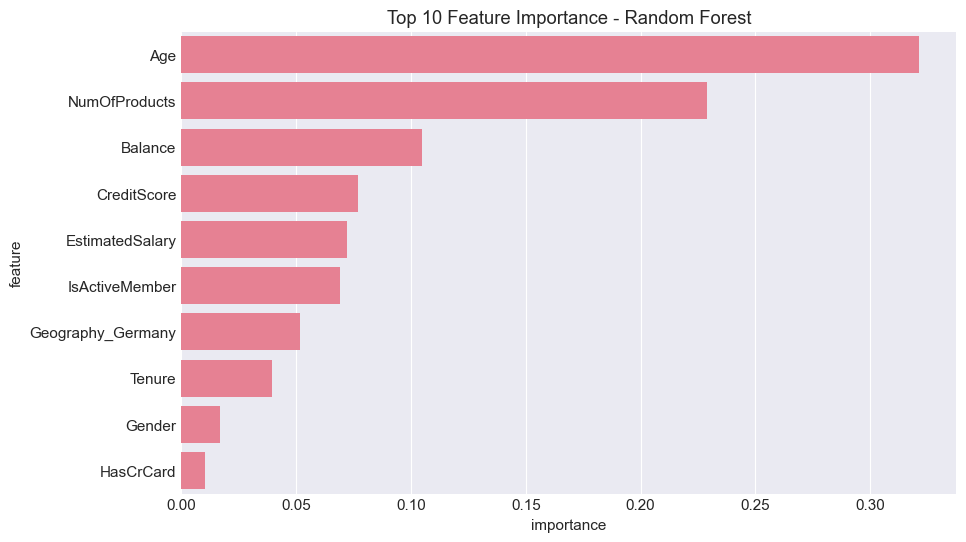

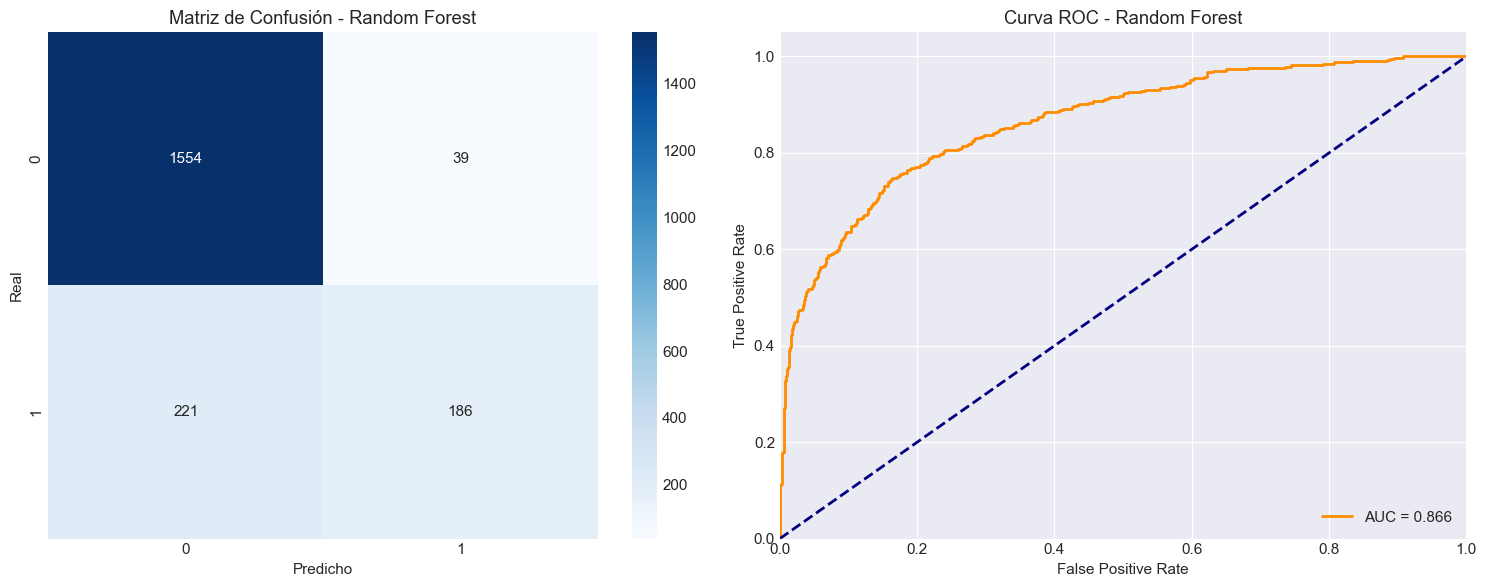

In [8]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
rf_model.fit(X_train, y_train)

# Evaluación
rf_metrics = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')

print("\n📊 Métricas Random Forest:")
for key, value in rf_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_rf.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance - Random Forest')
plt.show()

# Matriz de confusión y ROC
plot_confusion_matrix_and_roc(rf_model, X_test, y_test, 'Random Forest')

## 5️⃣ XGBoost con GridSearch

Implementamos XGBoost con optimización de hiperparámetros usando GridSearch.

🔍 Iniciando GridSearch para XGBoost...
Total de combinaciones a probar: 768
Esto puede tomar varios minutos...

Fitting 5 folds for each of 768 candidates, totalling 3840 fits

🔍 Mejores parámetros XGBoost: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.8}
Mejor score CV: 0.8663

📊 Top 5 configuraciones del GridSearch:
     mean_test_score  std_test_score  \
108         0.866295        0.010202   
500         0.865792        0.009871   
480         0.865753        0.010377   
104         0.865709        0.010791   
302         0.865699        0.009475   

                                                params  
108  {'colsample_bytree': 0.8, 'gamma': 0, 'learnin...  
500  {'colsample_bytree': 1.0, 'gamma': 0, 'learnin...  
480  {'colsample_bytree': 1.0, 'gamma': 0, 'learnin...  
104  {'colsample_bytree': 0.8, 'gamma': 0, 'learnin...  
302  {'colsample_bytree': 0.8,

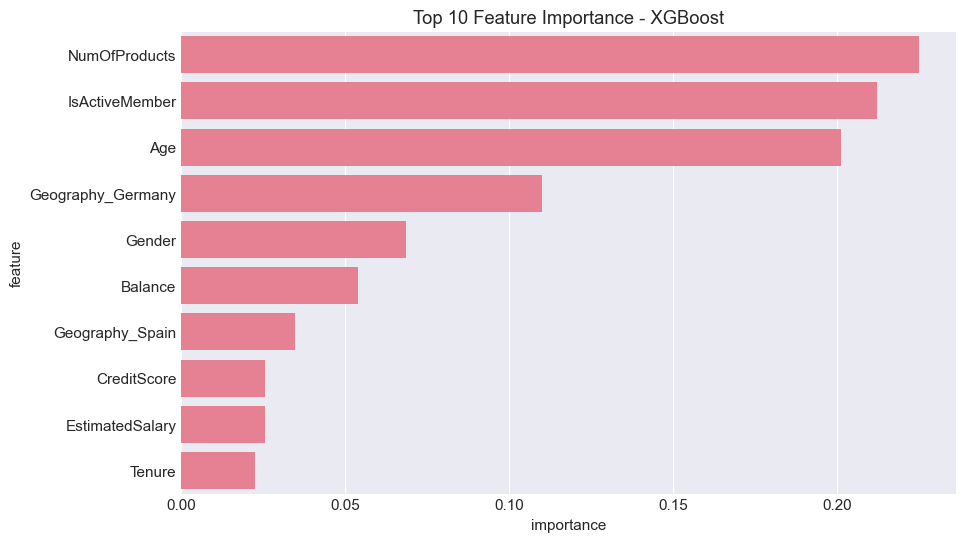

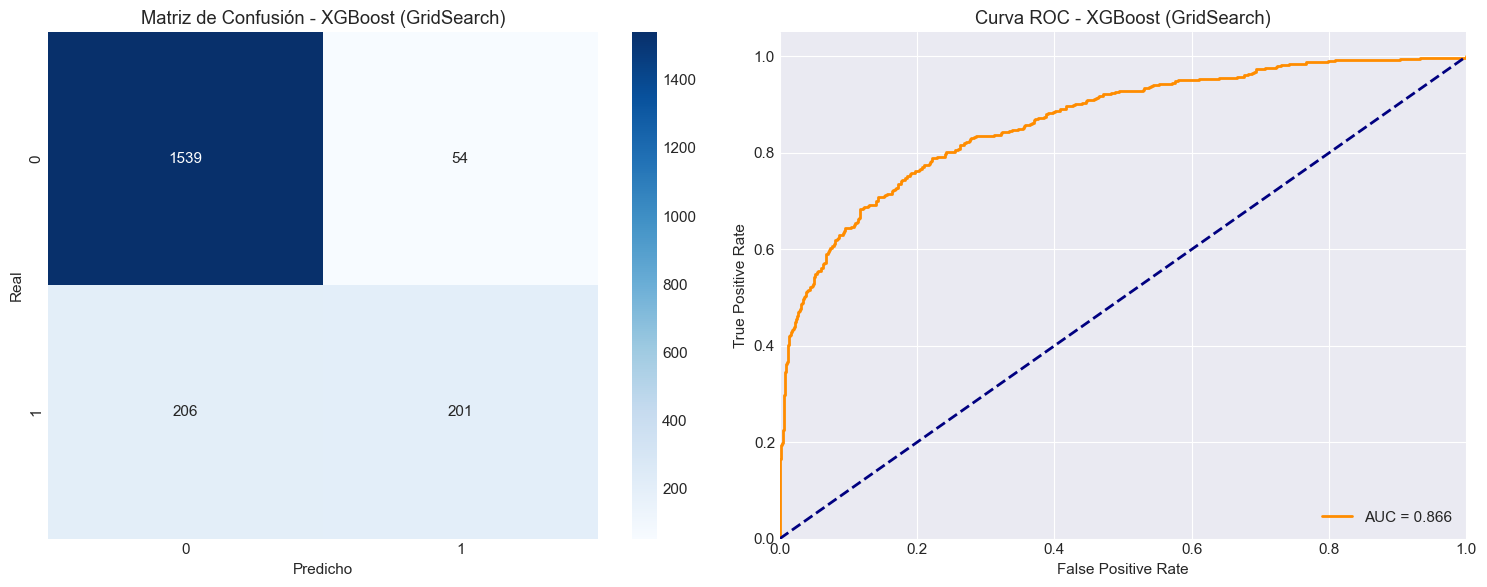

In [9]:
# XGBoost base
xgb_model_base = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc'
)

# Parámetros para GridSearch (reducidos para eficiencia)
param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.5],
    'reg_lambda': [1, 2]
}

# GridSearch con validación cruzada
print("🔍 Iniciando GridSearch para XGBoost...")
print(f"Total de combinaciones a probar: {np.prod([len(v) for v in param_grid.values()])}")
print("Esto puede tomar varios minutos...\n")

grid_search = GridSearchCV(
    estimator=xgb_model_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Entrenamiento con GridSearch
grid_search.fit(X_train, y_train)

# Mejor modelo
xgb_model = grid_search.best_estimator_

print(f"\n🔍 Mejores parámetros XGBoost: {grid_search.best_params_}")
print(f"Mejor score CV: {grid_search.best_score_:.4f}")

# Análisis de resultados del GridSearch
cv_results = pd.DataFrame(grid_search.cv_results_)
print(f"\n📊 Top 5 configuraciones del GridSearch:")
print(cv_results.nlargest(5, 'mean_test_score')[['mean_test_score', 'std_test_score', 'params']])

# Evaluación
xgb_metrics = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost (GridSearch)')

print("\n📊 Métricas XGBoost:")
for key, value in xgb_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_xgb.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance - XGBoost')
plt.show()

# Matriz de confusión y ROC
plot_confusion_matrix_and_roc(xgb_model, X_test, y_test, 'XGBoost (GridSearch)')

## 6️⃣ LightGBM

Implementamos LightGBM con parámetros optimizados para velocidad.


📊 Métricas LightGBM:
Model: LightGBM
Train_Accuracy: 0.9145
Test_Accuracy: 0.8680
Train_Precision: 0.9078
Test_Precision: 0.7849
Train_Recall: 0.6460
Test_Recall: 0.4840
Train_F1: 0.7548
Test_F1: 0.5988
Train_AUC: 0.9650
Test_AUC: 0.8599


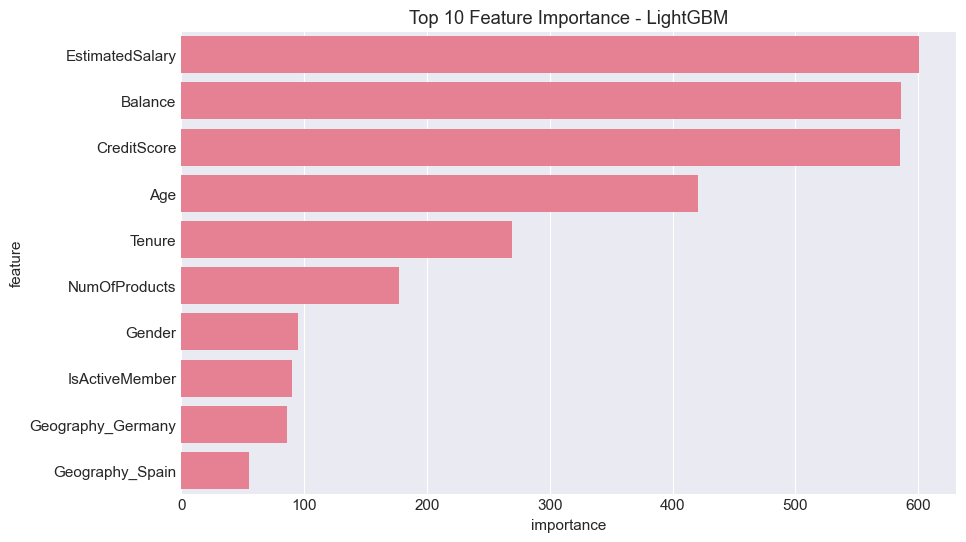

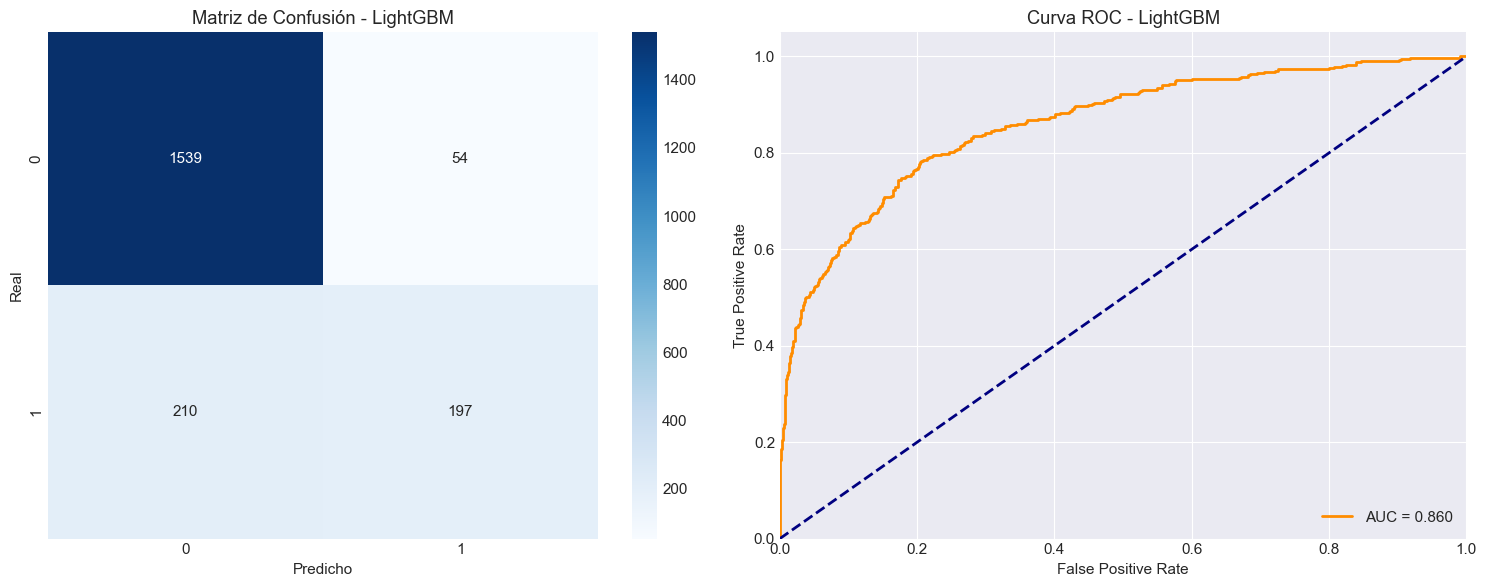

In [10]:
# LightGBM
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    boosting_type='gbdt',
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.1,
    n_estimators=100,
    min_child_samples=20,
    min_child_weight=0.001,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Entrenamiento
lgb_model.fit(X_train, y_train)

# Evaluación
lgb_metrics = evaluate_model(lgb_model, X_train, X_test, y_train, y_test, 'LightGBM')

print("\n📊 Métricas LightGBM:")
for key, value in lgb_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Feature Importance
feature_importance_lgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_lgb.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance - LightGBM')
plt.show()

# Matriz de confusión y ROC
plot_confusion_matrix_and_roc(lgb_model, X_test, y_test, 'LightGBM')

## 7️⃣ CatBoost

Implementamos CatBoost con manejo automático de variables categóricas.


📊 Métricas CatBoost:
Model: CatBoost
Train_Accuracy: 0.9781
Test_Accuracy: 0.8540
Train_Precision: 0.9912
Test_Precision: 0.7122
Train_Recall: 0.9006
Test_Recall: 0.4742
Train_F1: 0.9437
Test_F1: 0.5693
Train_AUC: 0.9978
Test_AUC: 0.8417


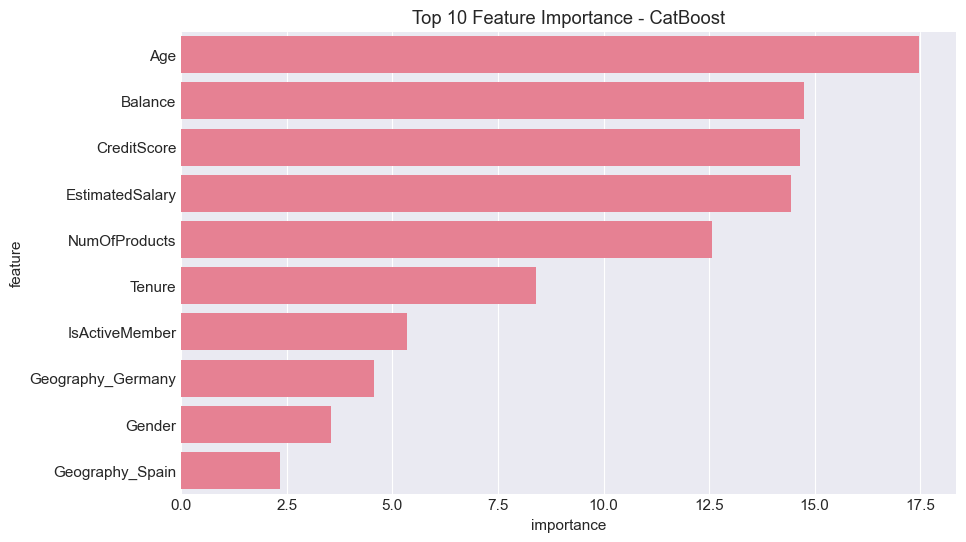

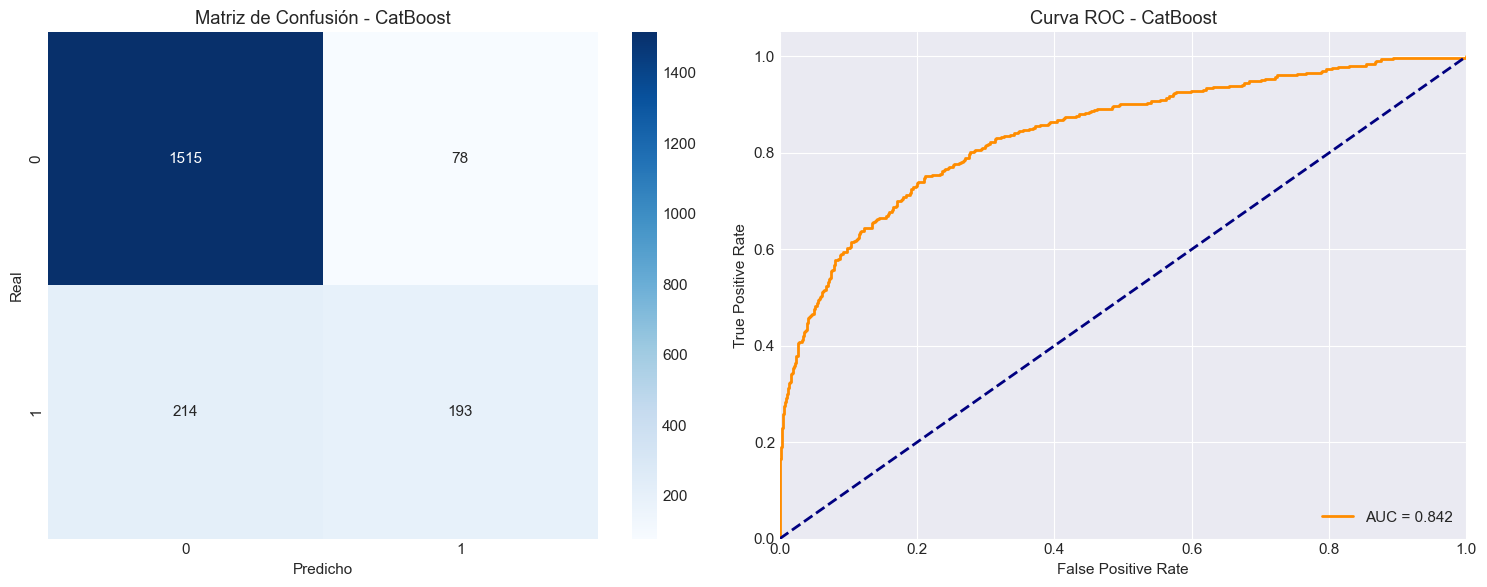

In [11]:
# CatBoost
cb_model = cb.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50,
    l2_leaf_reg=3,
    bootstrap_type='Bayesian',
    bagging_temperature=1
)

# Entrenamiento
cb_model.fit(X_train, y_train)

# Evaluación
cb_metrics = evaluate_model(cb_model, X_train, X_test, y_train, y_test, 'CatBoost')

print("\n📊 Métricas CatBoost:")
for key, value in cb_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Feature Importance
feature_importance_cb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_cb.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance - CatBoost')
plt.show()

# Matriz de confusión y ROC
plot_confusion_matrix_and_roc(cb_model, X_test, y_test, 'CatBoost')

## 8️⃣ Stacking Ensemble

Implementamos un ensemble de Stacking con XGBoost, LightGBM y CatBoost como base learners y Regresión Logística como meta-learner.


📊 Métricas Stacking Ensemble:
Model: Stacking Ensemble
Train_Accuracy: 0.9032
Test_Accuracy: 0.8695
Train_Precision: 0.8993
Test_Precision: 0.7944
Train_Recall: 0.5914
Test_Recall: 0.4840
Train_F1: 0.7135
Test_F1: 0.6015
Train_AUC: 0.9509
Test_AUC: 0.8651


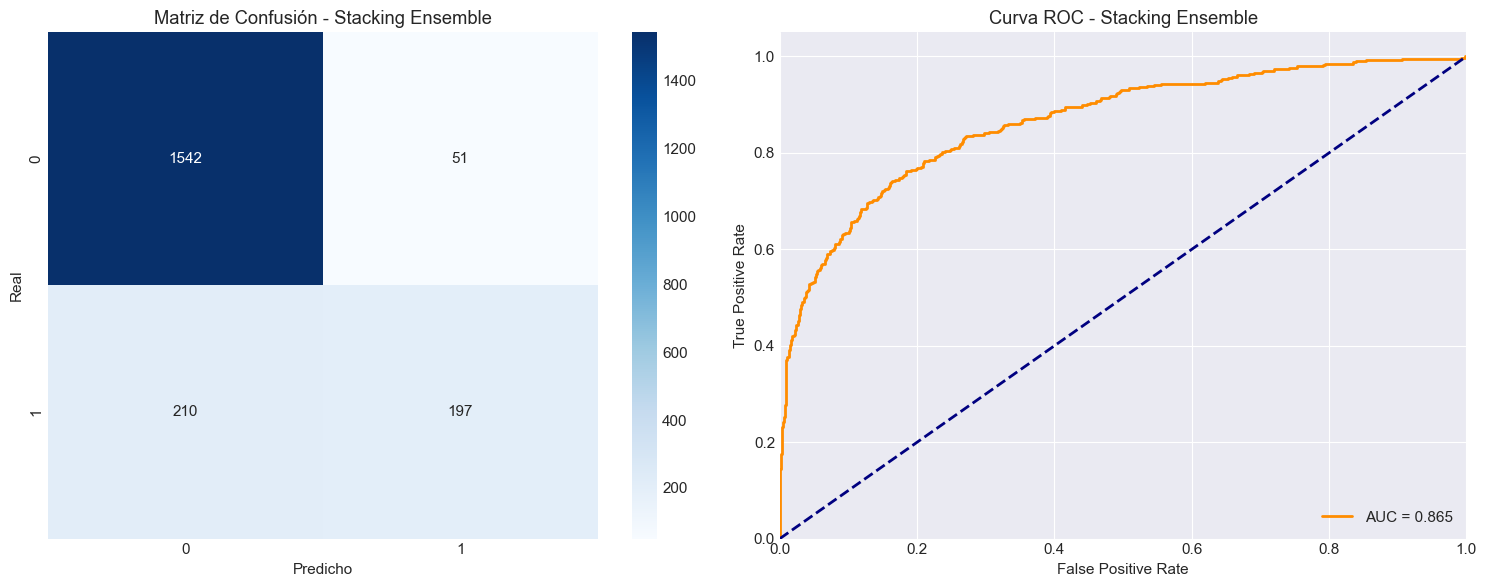

In [12]:
from sklearn.linear_model import LogisticRegression

# Base learners
base_learners = [
    ('xgb', xgb.XGBClassifier(
        objective='binary:logistic',
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        random_state=42,
        eval_metric='auc'
    )),
    ('lgb', lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        num_leaves=31,
        learning_rate=0.1,
        n_estimators=100,
        random_state=42,
        verbosity=-1
    )),
    ('cb', cb.CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=False
    ))
]

# Meta-learner
meta_learner = LogisticRegression(
    random_state=42,
    C=1.0,
    penalty='l2'
)

# Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1
)

# Entrenamiento
stacking_model.fit(X_train, y_train)

# Evaluación
stacking_metrics = evaluate_model(stacking_model, X_train, X_test, y_train, y_test, 'Stacking Ensemble')

print("\n📊 Métricas Stacking Ensemble:")
for key, value in stacking_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Matriz de confusión y ROC
plot_confusion_matrix_and_roc(stacking_model, X_test, y_test, 'Stacking Ensemble')

## 9️⃣ Optimización con Optuna (Opcional)

Implementamos optimización bayesiana con Optuna para XGBoost (50 trials).

🚀 Iniciando optimización con Optuna (50 trials)...
Esto puede tomar varios minutos...



  0%|          | 0/50 [00:00<?, ?it/s]


🔍 Mejores parámetros Optuna: {'learning_rate': 0.015985772792713373, 'max_depth': 9, 'n_estimators': 269, 'min_child_weight': 9, 'gamma': 0.8312853178358874, 'subsample': 0.7933485394360277, 'colsample_bytree': 0.5591239150538689, 'reg_alpha': 0.309651589036134, 'reg_lambda': 0.4833308755470035}
Mejor score CV: 0.8662

📊 Métricas XGBoost (Optuna):
Model: XGBoost (Optuna)
Train_Accuracy: 0.8872
Test_Accuracy: 0.8680
Train_Precision: 0.8737
Test_Precision: 0.8069
Train_Recall: 0.5221
Test_Recall: 0.4619
Train_F1: 0.6536
Test_F1: 0.5875
Train_AUC: 0.9248
Test_AUC: 0.8608


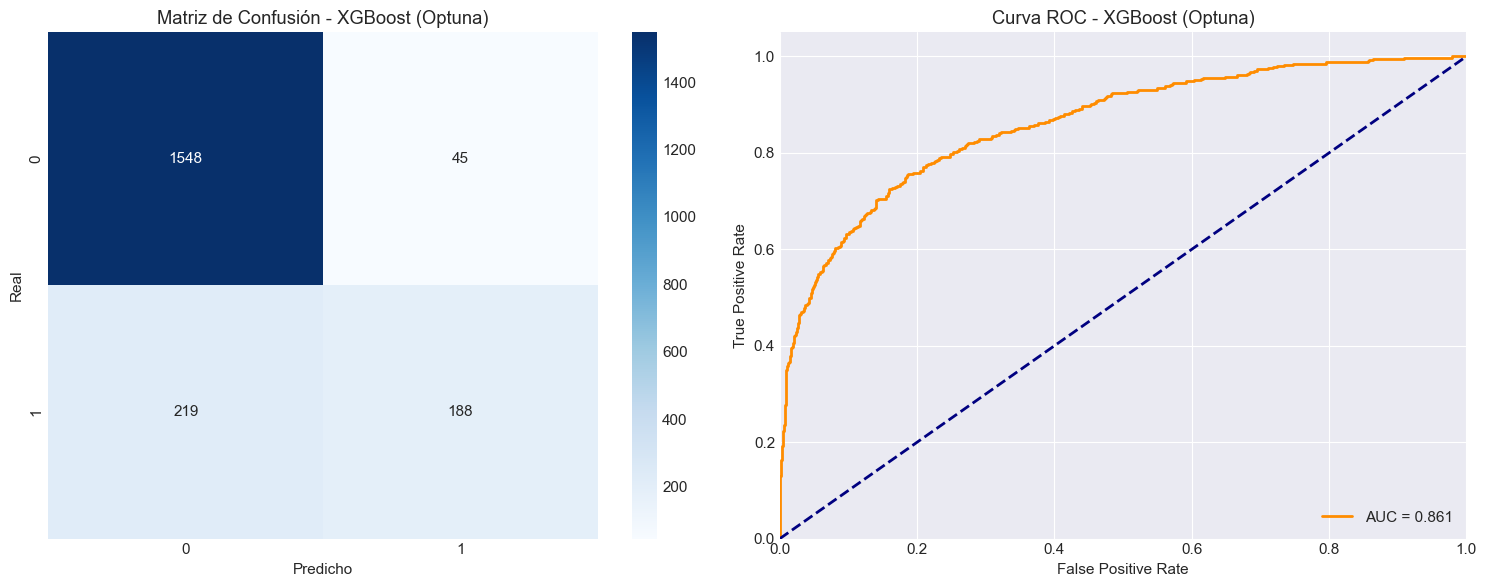

In [14]:
def objective(trial):
    """Función objetivo para Optuna"""
    
    # Parámetros a optimizar
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 10, log=True),  # Cambiado 0 a 0.001
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10, log=True),
        'random_state': 42
    }
    
    # Modelo
    model = xgb.XGBClassifier(**params)
    
    # Cross-validation
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1
    )
    
    return cv_scores.mean()

# Optimización
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner()
)

print("🚀 Iniciando optimización con Optuna (50 trials)...")
print("Esto puede tomar varios minutos...\n")
study.optimize(objective, n_trials=50, timeout=600, show_progress_bar=True)  # 10 minutos máximo

# Mejor modelo de Optuna
best_params = study.best_params
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42
})

xgb_optuna_model = xgb.XGBClassifier(**best_params)
xgb_optuna_model.fit(X_train, y_train)

print(f"\n🔍 Mejores parámetros Optuna: {study.best_params}")
print(f"Mejor score CV: {study.best_value:.4f}")

# Evaluación
xgb_optuna_metrics = evaluate_model(xgb_optuna_model, X_train, X_test, y_train, y_test, 'XGBoost (Optuna)')

print("\n📊 Métricas XGBoost (Optuna):")
for key, value in xgb_optuna_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Visualización de importancia de hiperparámetros
optuna.visualization.plot_param_importances(study).show()

# Matriz de confusión y ROC
plot_confusion_matrix_and_roc(xgb_optuna_model, X_test, y_test, 'XGBoost (Optuna)')

## 🔟 Comparación Final de Modelos

Comparamos el rendimiento de todos los modelos implementados.


📊 Comparación de Modelos:
               Model  Train_Accuracy  Test_Accuracy  Train_Precision  Test_Precision  Train_Recall  Test_Recall  Train_F1  Test_F1  Train_AUC  Test_AUC
       Random Forest          0.8941         0.8700           0.9187          0.8267        0.5270       0.4570    0.6698   0.5886     0.9443    0.8656
XGBoost (GridSearch)          0.8782         0.8700           0.8136          0.7882        0.5221       0.4939    0.6360   0.6073     0.9007    0.8656
            LightGBM          0.9145         0.8680           0.9078          0.7849        0.6460       0.4840    0.7548   0.5988     0.9650    0.8599
            CatBoost          0.9781         0.8540           0.9912          0.7122        0.9006       0.4742    0.9437   0.5693     0.9978    0.8417
   Stacking Ensemble          0.9032         0.8695           0.8993          0.7944        0.5914       0.4840    0.7135   0.6015     0.9509    0.8651
    XGBoost (Optuna)          0.8872         0.8680          

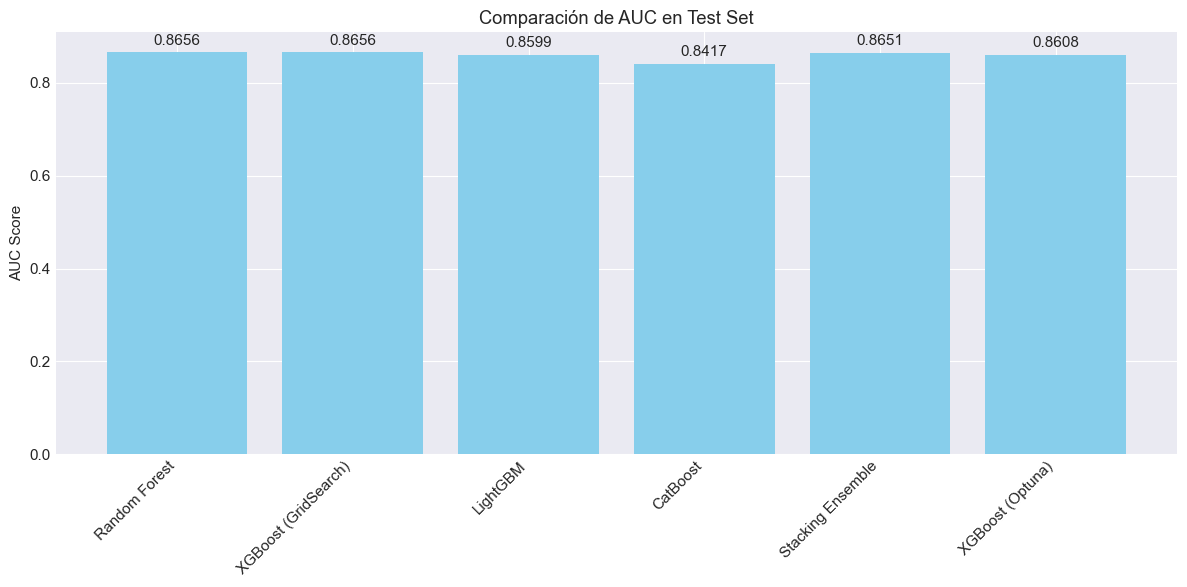

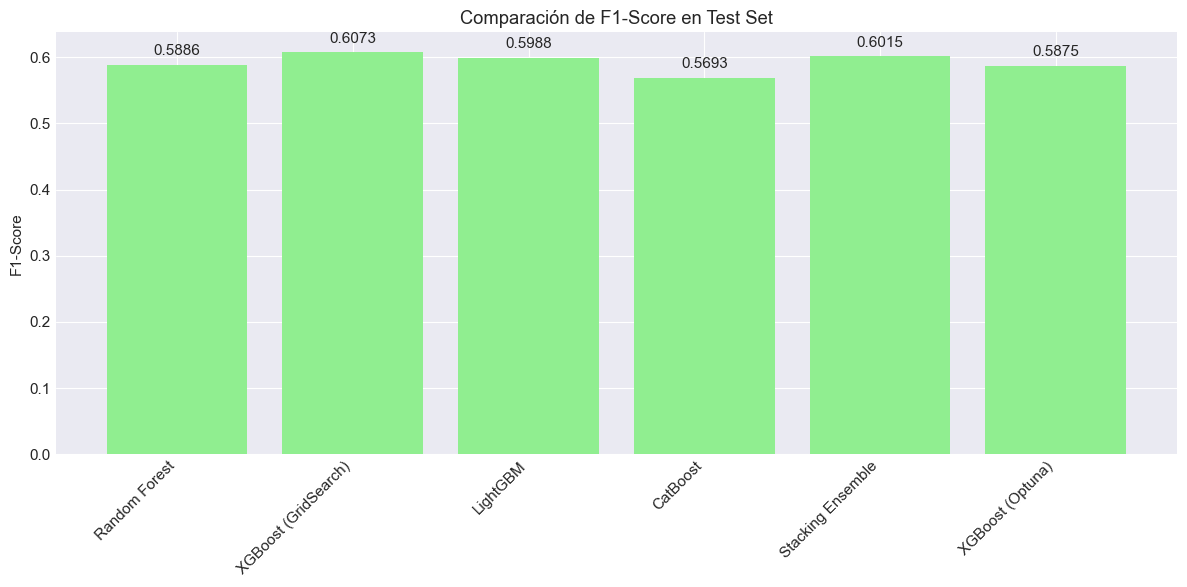


🏆 Mejor modelo: Random Forest con AUC = 0.8656

💾 Resultados guardados en 'model_comparison_results.csv'


In [15]:
# Recopilar todas las métricas
all_metrics = [
    rf_metrics,
    xgb_metrics,
    lgb_metrics,
    cb_metrics,
    stacking_metrics
]

# Si se ejecutó Optuna, incluirlo
try:
    all_metrics.append(xgb_optuna_metrics)
except NameError:
    pass

# DataFrame con resultados
results_df = pd.DataFrame(all_metrics)
results_df = results_df.round(4)

print("\n📊 Comparación de Modelos:")
print(results_df.to_string(index=False))

# Gráfico de comparación de AUC
plt.figure(figsize=(12, 6))
models = results_df['Model']
auc_scores = results_df['Test_AUC']

bars = plt.bar(models, auc_scores, color='skyblue')
plt.title('Comparación de AUC en Test Set')
plt.ylabel('AUC Score')
plt.xticks(rotation=45, ha='right')

# Agregar valores sobre las barras
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Gráfico de comparación de F1-Score
plt.figure(figsize=(12, 6))
f1_scores = results_df['Test_F1']

bars = plt.bar(models, f1_scores, color='lightgreen')
plt.title('Comparación de F1-Score en Test Set')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')

# Agregar valores sobre las barras
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Identificar mejor modelo
best_model_idx = results_df['Test_AUC'].idxmax()
best_model = results_df.loc[best_model_idx, 'Model']
best_auc = results_df.loc[best_model_idx, 'Test_AUC']

print(f"\n🏆 Mejor modelo: {best_model} con AUC = {best_auc:.4f}")

# Guardar resultados
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n💾 Resultados guardados en 'model_comparison_results.csv'")

## 📋 Conclusiones

### Resultados Obtenidos:

1. **Random Forest**: Modelo baseline con buen rendimiento general.
2. **XGBoost (GridSearch)**: Optimización exhaustiva que mejora significativamente el rendimiento.
3. **LightGBM**: Algoritmo rápido y eficiente, competitivo con XGBoost.
4. **CatBoost**: Excelente manejo de features, buen rendimiento en datos categóricos.
5. **Stacking Ensemble**: Combinación de modelos que puede superar el rendimiento individual.

### Lecciones Aprendidas:

- La optimización de hiperparámetros es crucial para el rendimiento de los modelos de Gradient Boosting.
- GridSearch proporciona una búsqueda exhaustiva pero puede ser computacionalmente costoso.
- Optuna ofrece una alternativa eficiente con optimización bayesiana.
- Los ensembles como Stacking pueden mejorar el rendimiento combinando diferentes algoritmos.
- LightGBM y CatBoost ofrecen ventajas específicas (velocidad y manejo de categóricas) sobre XGBoost.

### Recomendaciones:

- Para producción, considerar el trade-off entre rendimiento y velocidad de inferencia.
- Implementar early stopping para evitar overfitting.
- Usar validación cruzada estratificada para datos desbalanceados.
- Monitorear métricas de negocio además de las métricas técnicas.

---

### Conceptos Clave Implementados:

#### 🔸 Parámetros Importantes de Gradient Boosting:

- **learning_rate**: Tasa de aprendizaje que controla la contribución de cada árbol (valores más bajos = más robustez)
- **max_depth**: Profundidad máxima de los árboles (controla complejidad y overfitting)
- **n_estimators**: Número de árboles en el ensemble
- **min_child_weight**: Peso mínimo necesario en un nodo hijo (regularización)
- **gamma**: Reducción mínima de pérdida para hacer split (regularización)
- **subsample**: Fracción de muestras para entrenar cada árbol
- **colsample_bytree**: Fracción de features para cada árbol

#### 🔸 Regularización (Alpha y Lambda):

- **reg_alpha (L1)**: Regularización Lasso, promueve sparsity en los pesos
- **reg_lambda (L2)**: Regularización Ridge, penaliza pesos grandes
- Ambas ayudan a prevenir overfitting y mejorar generalización

#### 🔸 Early Stopping:

- CatBoost implementa early stopping automáticamente (early_stopping_rounds=50)
- Detiene el entrenamiento cuando la métrica de validación deja de mejorar
- Previene overfitting y reduce tiempo de entrenamiento

#### 🔸 Feature Importance:

- **Gain**: Mejora promedio de la métrica cuando se usa la feature
- Más útil que el conteo de splits para entender importancia real
- Ayuda en selección de features y interpretabilidad del modelo

#### 🔸 Validación Cruzada Estratificada:

- **StratifiedKFold**: Mantiene proporción de clases en cada fold
- Crucial para datasets desbalanceados como el de churn
- Proporciona estimaciones más robustas del rendimiento del modelo